# 1027 HW — Chapter 4, Q13 (a–d)

This notebook uses the `Weekly` data from the ISLP package.

Tasks:
- (a) Numerical and graphical summaries; comment on patterns.
- (b) Logistic regression with `Direction` as response and `Lag1`–`Lag5` + `Volume` as predictors.
- (c) Confusion matrix and overall accuracy for (b).
- (d) Train on 1990–2008 using `Lag2` only; test on 2009–2010. Compute confusion matrix and accuracy.

In [ ]:
# Suppress seaborn FutureWarning about pandas get_group tuple keys
import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='seaborn._base')


In [13]:
# Setup: imports (with light auto-install if missing)
import sys, importlib, subprocess

def ensure(pkg, import_name=None):
    name = import_name or pkg
    try:
        importlib.import_module(name)
    except ModuleNotFoundError:
        print(f'Installing {pkg} ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

# Ensure common deps (safe to skip if already present)
for _pkg, _imp in [('ISLP','ISLP'), ('statsmodels','statsmodels'), ('seaborn','seaborn'), ('scikit-learn','sklearn')]:
    ensure(_pkg, _imp)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import confusion_matrix, accuracy_score
from ISLP import load_data

sns.set(style='ticks', context='notebook')
pd.set_option('display.precision', 3)


In [14]:
# Load Weekly data
Weekly = load_data('Weekly')
print(Weekly.shape)
display(Weekly.head())
print()
print('Columns:', list(Weekly.columns))
print()
print(Weekly.info())


(1089, 9)


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.155,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.149,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.160,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.162,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.154,1.178,Up



Columns: ['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today', 'Direction']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Year       1089 non-null   int64   
 1   Lag1       1089 non-null   float64 
 2   Lag2       1089 non-null   float64 
 3   Lag3       1089 non-null   float64 
 4   Lag4       1089 non-null   float64 
 5   Lag5       1089 non-null   float64 
 6   Volume     1089 non-null   float64 
 7   Today      1089 non-null   float64 
 8   Direction  1089 non-null   category
dtypes: category(1), float64(7), int64(1)
memory usage: 69.4 KB
None


## (a) Numerical and graphical summaries
> Produce some numerical and graphical summaries of the Weekly data. Do there appear to be any patterns?

In [15]:
# Numerical summaries
desc = Weekly.describe(include='all')
display(desc)
print()
print('Direction counts:')
display(Weekly['Direction'].value_counts())
print()
print('Correlation (numeric columns):')
display(Weekly.select_dtypes(include=[np.number]).corr())


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
count,1089.000,1089.000,1089.000,1089.000,1089.000,1089.000,1089.000,1089.000,1089
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Up
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,605
mean,2000.049,0.151,0.151,0.147,0.146,0.140,1.575,0.150,NaN
std,6.033,2.357,2.357,2.361,2.360,2.361,1.687,2.357,NaN
min,1990.000,-18.195,-18.195,-18.195,-18.195,-18.195,0.087,-18.195,NaN
25%,1995.000,-1.154,-1.154,-1.158,-1.158,-1.166,0.332,-1.154,NaN
50%,2000.000,0.241,0.241,0.241,0.238,0.234,1.003,0.241,NaN
75%,2005.000,1.405,1.409,1.409,1.409,1.405,2.054,1.405,NaN



Direction counts:


Direction
Up      605
Down    484
Name: count, dtype: int64


Correlation (numeric columns):


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000,-0.032,-0.033,-0.030,-0.031,-0.031,0.842,-0.032
Lag1,-0.032,1.000,-0.075,0.059,-0.071,-0.008,-0.065,-0.075
Lag2,-0.033,-0.075,1.000,-0.076,0.058,-0.072,-0.086,0.059
Lag3,-0.030,0.059,-0.076,1.000,-0.075,0.061,-0.069,-0.071
Lag4,-0.031,-0.071,0.058,-0.075,1.000,-0.076,-0.061,-0.008
Lag5,-0.031,-0.008,-0.072,0.061,-0.076,1.000,-0.059,0.011
Volume,0.842,-0.065,-0.086,-0.069,-0.061,-0.059,1.000,-0.033
Today,-0.032,-0.075,0.059,-0.071,-0.008,0.011,-0.033,1.000


C:\Users\user\AppData\Roaming\Python\Python311\site-packages\seaborn\relational.py:292: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sub_data = grouped.apply(agg, other).reset_index()


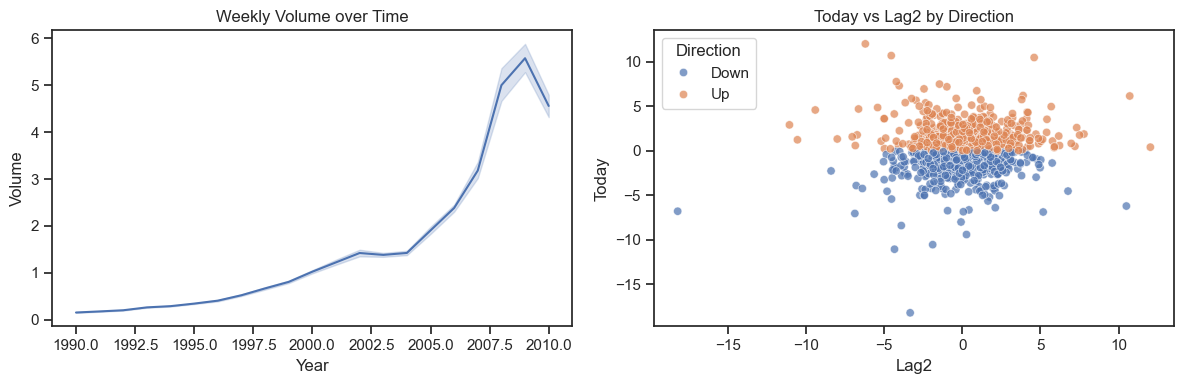

C:\Users\user\AppData\Roaming\Python\Python311\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\user\AppData\Roaming\Python\Python311\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\user\AppData\Roaming\Python\Python311\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\user\AppDa

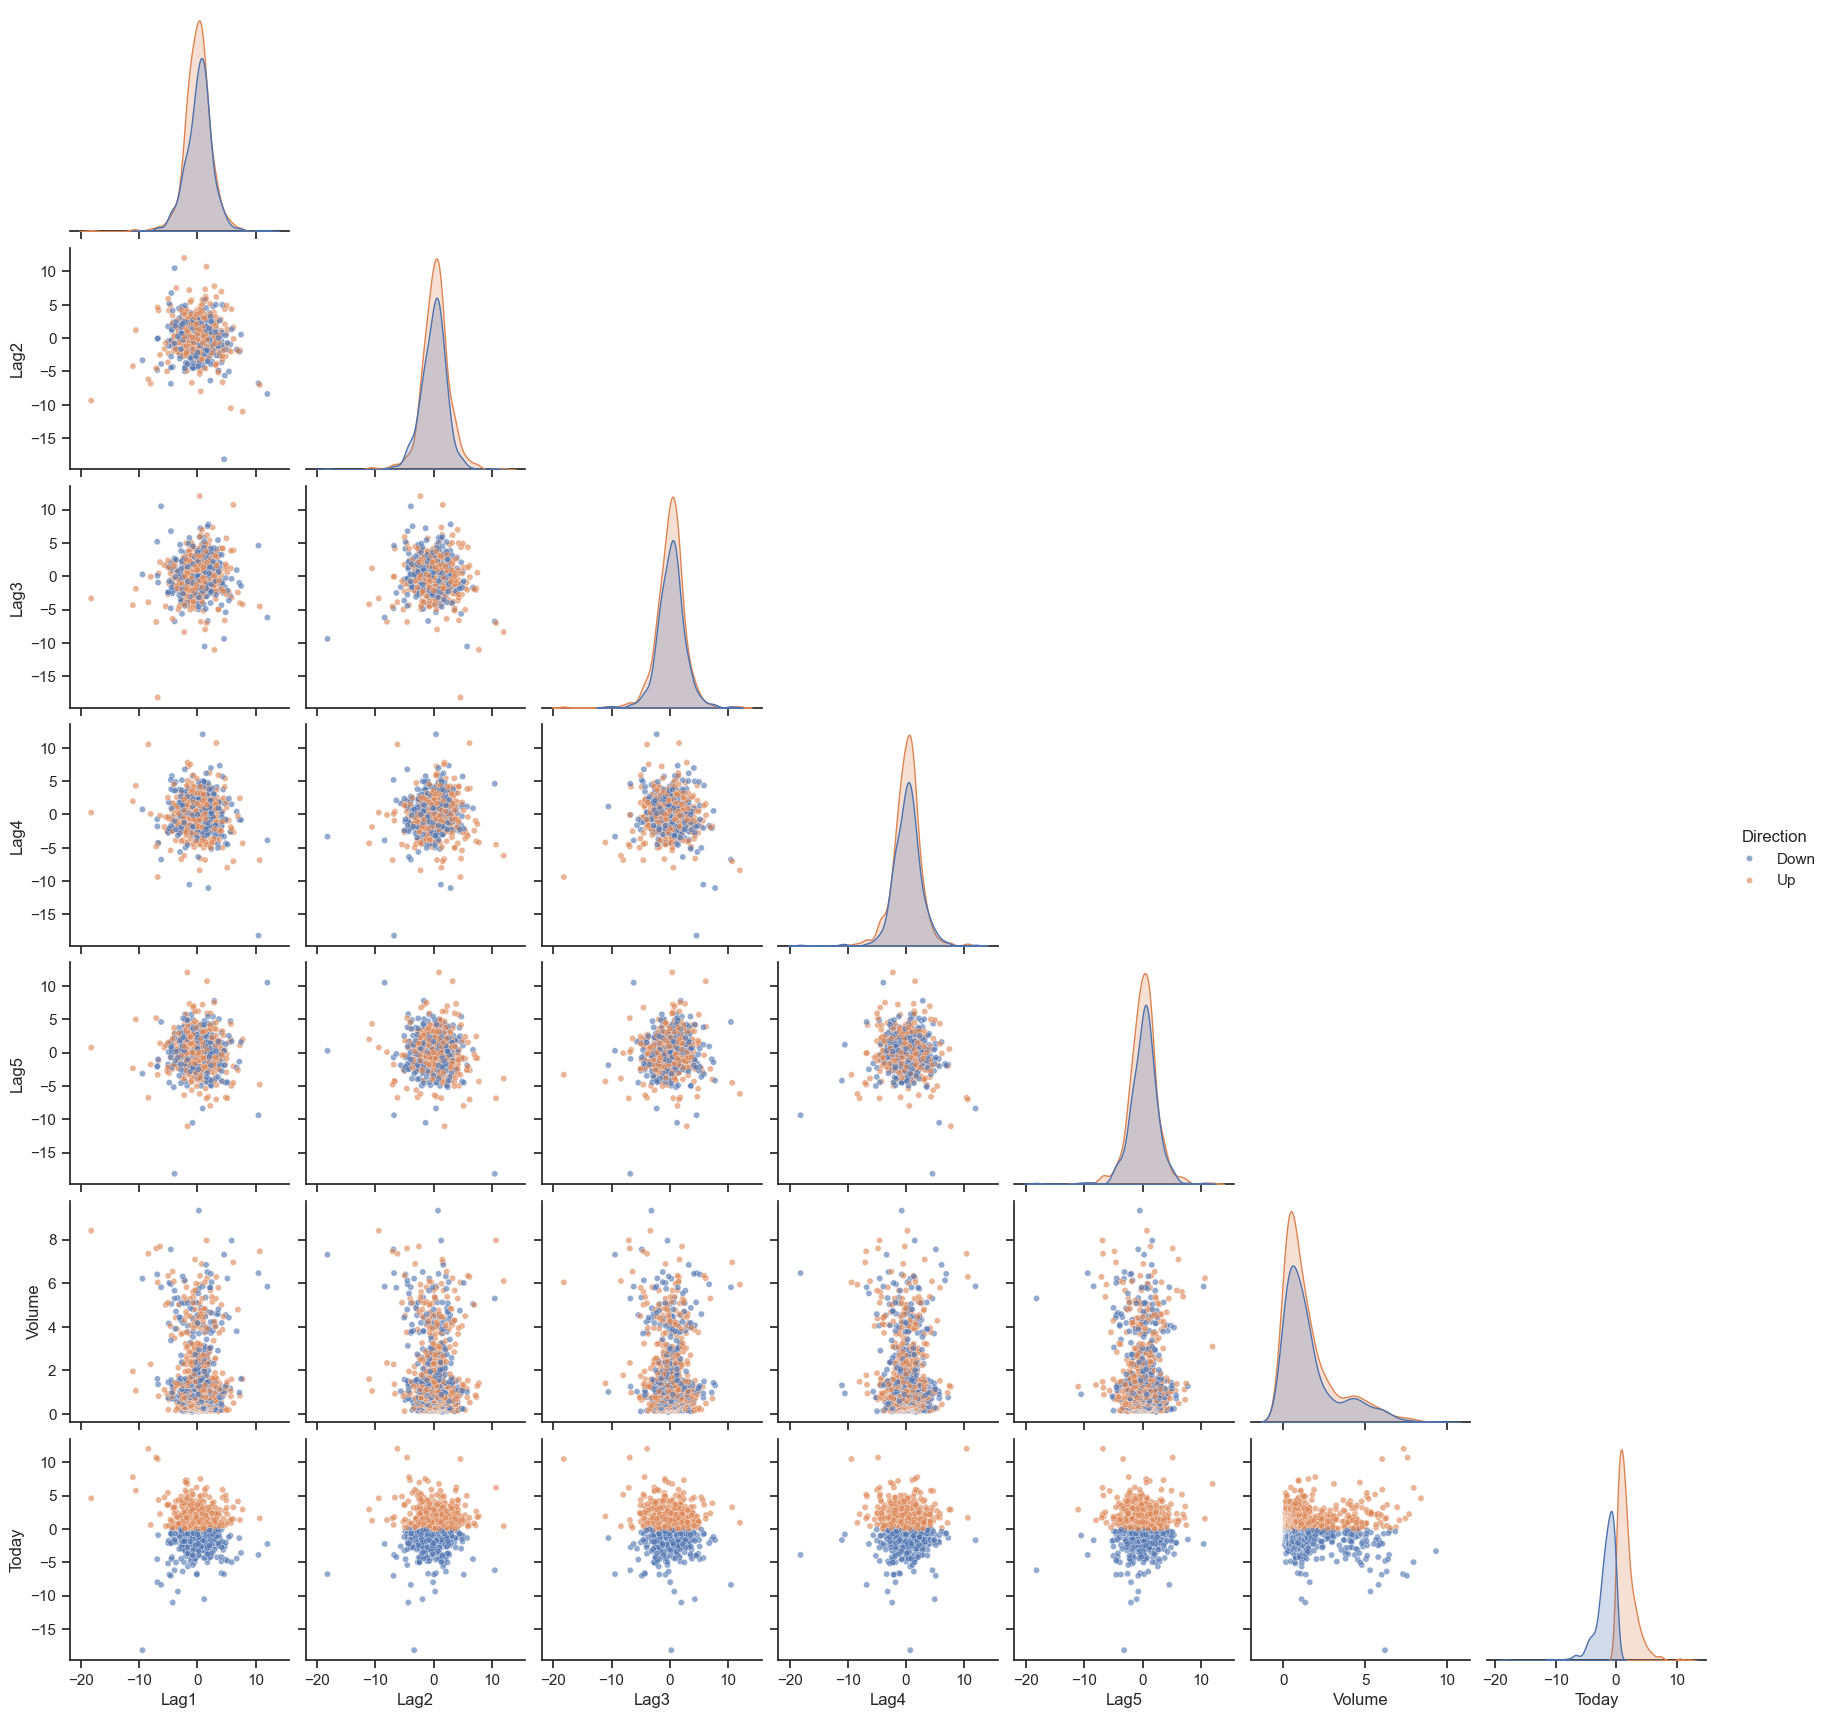

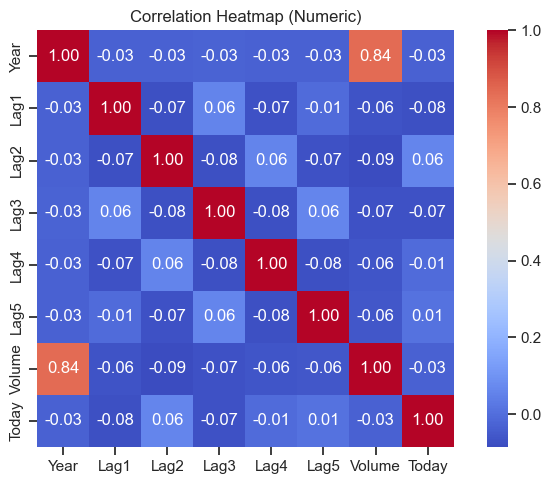

In [16]:
# Graphical summaries
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.lineplot(ax=axes[0], data=Weekly, x='Year', y='Volume')
axes[0].set_title('Weekly Volume over Time')
sns.scatterplot(ax=axes[1], data=Weekly, x='Lag2', y='Today', hue='Direction', alpha=0.7)
axes[1].set_title('Today vs Lag2 by Direction')
plt.tight_layout()
plt.show()

# Pairwise relationships among lags, Volume, and Today
cols = ['Lag1','Lag2','Lag3','Lag4','Lag5','Volume','Today','Direction']
sns.pairplot(Weekly[cols], hue='Direction', corner=True, plot_kws={'alpha':0.6, 's':20})
plt.show()

# Correlation heatmap for numeric variables
plt.figure(figsize=(7,5))
corr = Weekly.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap (Numeric)')
plt.tight_layout()
plt.show()


### (a) Notes / Observations
- Add brief comments here after inspecting the tables and plots.
- Typical findings: weak correlations among lags and `Today`; `Lag2` sometimes shows a mild signal.

## (b) Logistic regression: Direction ~ Lag1 + ... + Lag5 + Volume
> Use the full data set to perform a logistic regression with Direction as the response and the five lag variables plus Volume as predictors. Use the summary function to print the results. Do any of the predictors appear to be statistically significant? If so, which ones?

In [17]:
# Prepare data for statsmodels Logit (for p-values)
y = (Weekly['Direction'] == 'Up').astype(int)
X = Weekly[['Lag1','Lag2','Lag3','Lag4','Lag5','Volume']]
X_const = sm.add_constant(X)
logit_full = sm.Logit(y, X_const).fit(disp=False)
print(logit_full.summary())

# Identify significant predictors at alpha=0.05
sig = logit_full.pvalues[logit_full.pvalues < 0.05]
print('Significant predictors (p<0.05):')
display(sig)


                           Logit Regression Results                           
Dep. Variable:              Direction   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1082
Method:                           MLE   Df Model:                            6
Date:                Mon, 03 Nov 2025   Pseudo R-squ.:                0.006580
Time:                        01:11:25   Log-Likelihood:                -743.18
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                    0.1313
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2669      0.086      3.106      0.002       0.098       0.435
Lag1          -0.0413      0.026     -1.563      0.118      -0.093       0.010
Lag2           0.0584      0.027      2.175      0.0

const    0.002
Lag2     0.030
dtype: float64

## (c) Confusion matrix and accuracy for (b)
> Compute the confusion matrix and overall fraction of correct predictions. Explain what the confusion matrix is telling you about the types of mistakes made by logistic regression.

In [18]:
proba_full = logit_full.predict(X_const)
pred_full = np.where(proba_full >= 0.5, 'Up', 'Down')
cm = confusion_matrix(Weekly['Direction'], pred_full, labels=['Down','Up'])
acc = accuracy_score(Weekly['Direction'], pred_full)

cm_df = pd.DataFrame(cm, index=['Actual Down','Actual Up'], columns=['Pred Down','Pred Up'])
display(cm_df)
print(f'Overall accuracy: {acc:.3f}')

fp = cm[0,1]  # predict Up when actual Down
fn = cm[1,0]  # predict Down when actual Up
print(f'FP (Down→Up): {fp}, FN (Up→Down): {fn}')


,Pred Down,Pred Up
Actual Down,54,430
Actual Up,48,557


Overall accuracy: 0.561
FP (Down→Up): 430, FN (Up→Down): 48


## (d) Train on 1990–2008 with Lag2 only; test on 2009–2010
> Now fit the logistic regression model using a training data period from 1990 to 2008, with Lag2 as the only predictor. Compute the confusion matrix and the overall fraction of correct predictions for the held out data (that is, the data from 2009 and 2010).

In [19]:
train = Weekly[Weekly['Year'] <= 2008].copy()
test  = Weekly[Weekly['Year'] >= 2009].copy()

y_tr = (train['Direction'] == 'Up').astype(int)
X_tr = sm.add_constant(train[['Lag2']])
y_te = test['Direction']
X_te = sm.add_constant(test[['Lag2']])

logit_lag2 = sm.Logit(y_tr, X_tr).fit(disp=False)
print(logit_lag2.summary())

proba_te = logit_lag2.predict(X_te)
pred_te = np.where(proba_te >= 0.5, 'Up', 'Down')
cm_te = confusion_matrix(y_te, pred_te, labels=['Down','Up'])
acc_te = accuracy_score(y_te, pred_te)

cm_te_df = pd.DataFrame(cm_te, index=['Actual Down','Actual Up'], columns=['Pred Down','Pred Up'])
display(cm_te_df)
print(f'Test accuracy (2009–2010): {acc_te:.3f}')


                           Logit Regression Results                           
Dep. Variable:              Direction   No. Observations:                  985
Model:                          Logit   Df Residuals:                      983
Method:                           MLE   Df Model:                            1
Date:                Mon, 03 Nov 2025   Pseudo R-squ.:                0.003076
Time:                        01:11:25   Log-Likelihood:                -675.27
converged:                       True   LL-Null:                       -677.35
Covariance Type:            nonrobust   LLR p-value:                   0.04123
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2033      0.064      3.162      0.002       0.077       0.329
Lag2           0.0581      0.029      2.024      0.043       0.002       0.114


,Pred Down,Pred Up
Actual Down,9,34
Actual Up,5,56


Test accuracy (2009–2010): 0.625
